# Ablation: Return Premium for Missing vs. Observed Characteristics by Firm Quality (5-Year Sample)

This notebook is a 5-year version of the ablation using `raw_rank_trunk_chars_5yr.npz` (2016–2020, 60 months).
It segments firms along several quality dimensions and computes the **value-weighted return premium** for firms
with *missing* vs. *observed* financial characteristics within each segment.

**Segmentation dimensions:**
1. **Size quintiles** (market equity, ME)
2. **Fama-French 10 industries** (via SIC codes)
3. **Profitability quintiles** (operating profitability, OP)
4. **Leverage quintiles** (LEV)
5. **Book-to-market quintiles** (B2M, value vs. growth)
6. **Time sub-periods** (2016–2017 vs. 2018–2020)

In [47]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rcParams
rcParams.update({'figure.autolayout': True})

from imputation_utils import char_groupings, char_maps

data = np.load('../data/raw_rank_trunk_chars_5yr.npz')
percentile_rank_chars = data['rank_chars']
regular_chars        = data['raw_chars']
chars                = data['chars']
dates                = data['dates']
return_panel         = data['returns']
permnos              = data['permnos']
rts                  = data['rfs']
monthly_updates      = data['monthly_updates']

T, N, C = percentile_rank_chars.shape
print(f'Shape: {T} months x {N} firms x {C} characteristics')
print(f'Date range: {dates[0]} – {dates[-1]}')

Shape: 60 months x 22351 firms x 45 characteristics
Date range: 20160131 – 20201231


## Helper: core return-premium computation

For each characteristic `c` and time `t`, we form two value-weighted portfolios restricted to firms in a given segment mask:
- **Observed**: characteristic `c` is not missing at `t`
- **Missing (not at start)**: characteristic `c` is missing at `t` but was observed at some prior `t' < t`

Returns are measured 6 months forward (matching the paper).
WARMUP is set to 12 months (one year) given the shorter 5-year sample.

In [48]:
PORT_TGT_CHARS = [
    'A2ME', 'AT', 'ATO', 'B2M', 'C2A', 'CF2B', 'CF2P', 'CTO', 'D2A', 'DPI2A',
    'E2P', 'FC2Y', 'INV', 'LEV', 'NI', 'NOA', 'OA', 'OL', 'OP', 'PCM',
    'PM', 'PROF', 'Q', 'RNA', 'ROA', 'ROE', 'S2P', 'SGA2S',
]
RETURN_LAG    = 6
WARMUP        = 12  # reduced from 45 to suit the 60-month sample
MIN_MIS_FIRMS = 5   # drop months where the missing portfolio has too few firms


def vw_ret(mask, sizes, ret_vec, min_firms=1):
    """Value-weighted return for firms in mask at a single time step.
    Returns nan if the number of firms in the portfolio is below min_firms."""
    w = mask.astype(float) * np.nan_to_num(sizes)
    if np.sum(mask) < min_firms:
        return np.nan
    s = np.sum(w)
    if s < 1e-10:
        return np.nan
    return (w / s) @ np.nan_to_num(ret_vec)


MIN_VALID_MONTHS = 6    # require at least this many valid months before reporting a premium


def compute_return_premium(percentile_rank_chars, regular_chars, return_panel,
                           chars, segment_mask, return_lag=RETURN_LAG, start=WARMUP,
                           min_mis_firms=MIN_MIS_FIRMS, min_valid_months=MIN_VALID_MONTHS):
    """
    Compute per-characteristic return premium (missing – observed) within a segment.

    Parameters
    ----------
    segment_mask : (T, N) bool array  — True for firms in the segment at each time step.
                   A (N,) constant mask is also accepted.
    min_mis_firms : int
        Minimum number of firms required in the missing portfolio for a month to
        contribute to the average.  Months below this threshold are treated as nan
        to avoid estimates driven by 1–2 extreme-return stocks.
    min_valid_months : int
        Minimum number of valid months (after the min_mis_firms filter) required
        to report a premium.  Characteristic/segment pairs with fewer valid months
        are set to nan in the output.

    Returns
    -------
    DataFrame with columns: char, obs_mean, mis_mean, premium, t_stat, n_obs, n_mis
    """
    size_ind = np.argwhere(chars == 'ME')[0][0]

    if segment_mask.ndim == 1:
        segment_mask = np.broadcast_to(segment_mask[np.newaxis, :],
                                        (percentile_rank_chars.shape[0], len(segment_mask)))

    prev_obs_mask = np.any(~np.isnan(percentile_rank_chars[:start]), axis=0)  # (N, C)

    obs_ts = {c: [] for c in PORT_TGT_CHARS}
    mis_ts = {c: [] for c in PORT_TGT_CHARS}

    for t in range(start, T - return_lag):
        sizes   = regular_chars[t, :, size_ind]
        ret_fwd = return_panel[t + return_lag]
        has_size   = ~np.isnan(sizes)
        has_return = ~np.isnan(ret_fwd)
        seg        = segment_mask[t]

        for char_name in PORT_TGT_CHARS:
            i       = np.argwhere(chars == char_name)[0][0]
            present = ~np.isnan(percentile_rank_chars[t, :, i])
            base    = has_size & has_return & seg

            p_obs = present & base
            p_mis = (~present) & prev_obs_mask[:, i] & base

            obs_ts[char_name].append(vw_ret(p_obs, sizes, ret_fwd))
            mis_ts[char_name].append(vw_ret(p_mis, sizes, ret_fwd, min_firms=min_mis_firms))

        prev_obs_mask = prev_obs_mask | (~np.isnan(percentile_rank_chars[t]))

    rows = []
    for char_name in PORT_TGT_CHARS:
        o = np.array(obs_ts[char_name])
        m = np.array(mis_ts[char_name])
        diff = m - o
        valid = ~np.isnan(diff)
        n = np.sum(valid)
        prem = np.nanmean(diff)
        tstat = (prem / (np.nanstd(diff) / np.sqrt(n))) if n > 1 else np.nan
        if n < min_valid_months:
            prem   = np.nan
            tstat  = np.nan
        rows.append(dict(
            char     = char_name,
            obs_mean = 1200 * np.nanmean(o),
            mis_mean = 1200 * np.nanmean(m),
            premium  = 1200 * prem,
            t_stat   = tstat,
            n_obs    = int(np.sum(~np.isnan(o))),
            n_mis    = int(np.sum(~np.isnan(m))),
        ))

    return pd.DataFrame(rows).set_index('char')


print('Helper functions defined.')

Helper functions defined.


## Baseline: full-sample return premium

Computes the aggregate result for the 5-year sample as a sanity check.

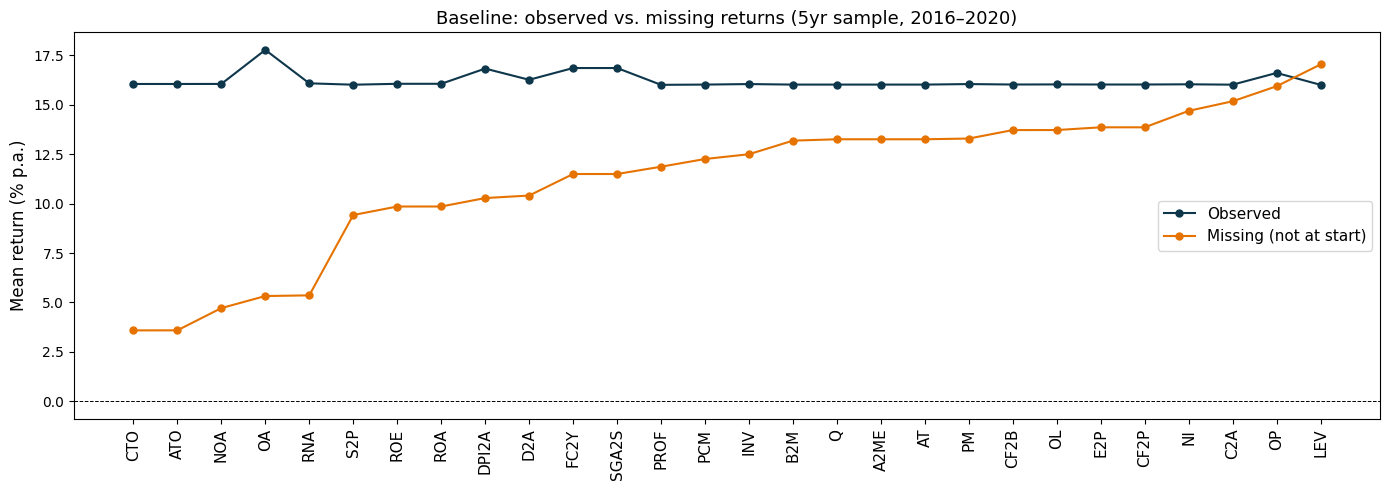

Avg premium (missing – observed): -4.92% p.a.
CPU times: user 953 ms, sys: 22.2 ms, total: 975 ms
Wall time: 991 ms


,obs_mean,mis_mean,premium,t_stat
char,,,,
A2ME,16.02,13.25,-2.76,-0.25
AT,16.02,13.25,-2.76,-0.25
ATO,16.05,3.59,-12.46,-1.39
B2M,16.02,13.18,-2.83,-0.26
C2A,16.01,15.17,-0.84,-0.08
CF2B,16.02,13.72,-2.30,-0.21
CF2P,16.02,13.86,-2.16,-0.20
CTO,16.05,3.59,-12.46,-1.39
D2A,16.26,10.41,-5.85,-1.14


In [49]:
%%time

all_firms_mask = np.ones((T, N), dtype=bool)
baseline = compute_return_premium(percentile_rank_chars, regular_chars, return_panel,
                                  chars, all_firms_mask)

ordering = np.argsort(baseline['mis_mean'].values)
ordered_chars   = baseline.index[ordering]
obs_vals        = baseline['obs_mean'].values[ordering]
mis_vals        = baseline['mis_mean'].values[ordering]

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(PORT_TGT_CHARS))
ax.plot(x, obs_vals, label='Observed', color='#0e374c', marker='o', markersize=5)
ax.plot(x, mis_vals, label='Missing (not at start)', color='#e67300', marker='o', markersize=5)
ax.axhline(0, color='k', linewidth=0.7, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels(ordered_chars, rotation=90, fontsize=11)
ax.set_ylabel('Mean return (% p.a.)', fontsize=12)
ax.set_title('Baseline: observed vs. missing returns (5yr sample, 2016–2020)', fontsize=13)
ax.legend(fontsize=11)
plt.savefig('../images-pdfs/ablation_baseline_returns_5yr.pdf', bbox_inches='tight')
plt.show()

print(f"Avg premium (missing – observed): {baseline['premium'].mean():.2f}% p.a.")
baseline[['obs_mean','mis_mean','premium','t_stat']].round(2)

## Segmentation 1: Size Quintiles

In [50]:
size_ind = np.argwhere(chars == 'ME')[0][0]
N_QUINTILES = 5

def build_quintile_masks(char_panel, char_idx, n=5):
    """Dynamic (T x N) quintile masks computed cross-sectionally each month."""
    T_, N_ = char_panel.shape[0], char_panel.shape[1]
    masks = [np.zeros((T_, N_), dtype=bool) for _ in range(n)]
    for t in range(T_):
        vals  = char_panel[t, :, char_idx]
        valid = ~np.isnan(vals)
        if np.sum(valid) < n:
            continue
        qs = np.nanquantile(vals[valid], np.linspace(0, 1, n + 1))
        for q in range(n):
            lo, hi = qs[q], qs[q + 1]
            in_bin = valid & (vals >= lo if q == 0 else vals > lo) & (vals <= hi)
            masks[q][t] = in_bin
    return masks

size_masks = build_quintile_masks(regular_chars, size_ind)
print('Size quintile firm counts at t=20:', [np.sum(m[20]) for m in size_masks])

Size quintile firm counts at t=20: [np.int64(821), np.int64(821), np.int64(821), np.int64(821), np.int64(821)]


In [51]:
%%time

size_results = []
for q, mask in enumerate(size_masks):
    print(f'  Computing size quintile {q+1}/5 ...')
    res = compute_return_premium(percentile_rank_chars, regular_chars, return_panel,
                                  chars, mask)
    res['quintile'] = q + 1
    size_results.append(res)

print('Done.')

  Computing size quintile 1/5 ...
  Computing size quintile 2/5 ...
  Computing size quintile 3/5 ...
  Computing size quintile 4/5 ...
  Computing size quintile 5/5 ...
Done.
CPU times: user 3.24 s, sys: 220 ms, total: 3.46 s
Wall time: 3.75 s


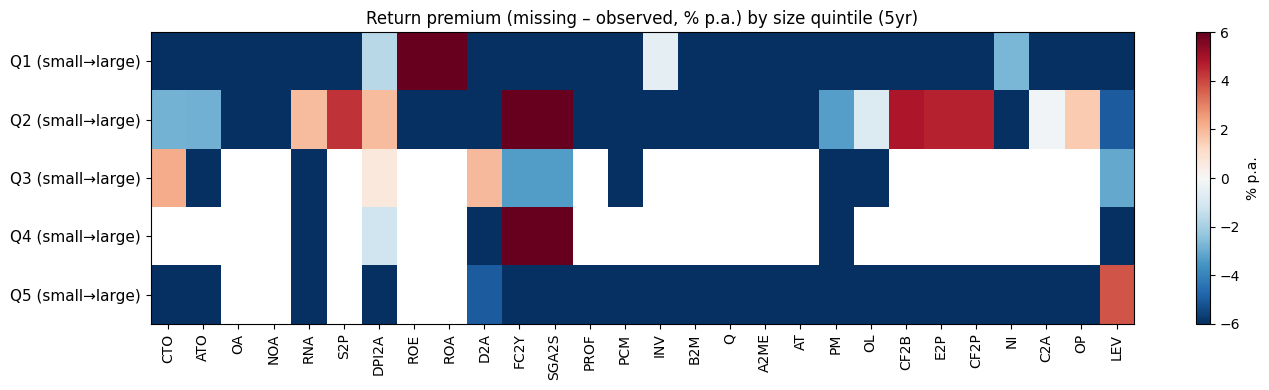

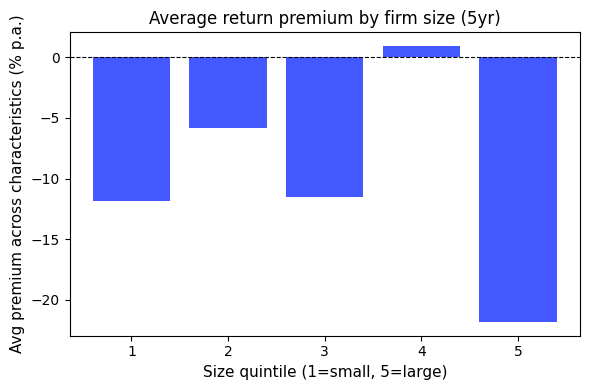

In [52]:
prem_matrix_size = np.array([r['premium'].values for r in size_results])  # (5, C)
ordered_chars_idx = np.argsort(baseline['premium'].values)
ordered_chars_names = [PORT_TGT_CHARS[i] for i in ordered_chars_idx]

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(prem_matrix_size[:, ordered_chars_idx], aspect='auto', cmap='RdBu_r',
               vmin=-6, vmax=6)
ax.set_yticks(range(5))
ax.set_yticklabels([f'Q{i+1} (small→large)' for i in range(5)], fontsize=11)
ax.set_xticks(range(len(PORT_TGT_CHARS)))
ax.set_xticklabels(ordered_chars_names, rotation=90, fontsize=10)
ax.set_title('Return premium (missing – observed, % p.a.) by size quintile (5yr)', fontsize=12)
plt.colorbar(im, ax=ax, label='% p.a.')
plt.savefig('../images-pdfs/ablation_size_heatmap_5yr.pdf', bbox_inches='tight')
plt.show()

avg_prems_size = [r['premium'].mean() for r in size_results]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(1, 6), avg_prems_size, color='#152eff', alpha=0.8)
ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
ax.set_xlabel('Size quintile (1=small, 5=large)', fontsize=11)
ax.set_ylabel('Avg premium across characteristics (% p.a.)', fontsize=11)
ax.set_title('Average return premium by firm size (5yr)', fontsize=12)
plt.savefig('../images-pdfs/ablation_size_avg_premium_5yr.pdf', bbox_inches='tight')
plt.show()

## Segmentation 2: Fama-French 10 Industries

In [53]:
sic_fic = pd.read_csv('../data/sic_fic.csv')

sic_latest = (
    sic_fic.sort_values('datadate')
    .dropna(subset=['sic'])
    .groupby('LPERMNO')['sic']
    .last()
    .reset_index()
)
sic_latest.columns = ['permno', 'sic']
sic_latest['sic'] = sic_latest['sic'].astype(int)


def sic_to_ff10(sic):
    """Fama-French 10-industry classification from SIC code."""
    if pd.isna(sic):
        return 'Other'
    s = int(sic)
    if (100 <= s <= 999) or (2000 <= s <= 2399) or (2700 <= s <= 2749) or \
       (2770 <= s <= 2799) or (3100 <= s <= 3199) or (3940 <= s <= 3989):
        return 'NoDur'
    if (2500 <= s <= 2519) or (2590 <= s <= 2599) or (3630 <= s <= 3659) or \
       s in [3710, 3711, 3714, 3716] or (3750 <= s <= 3751) or \
       s == 3792 or (3900 <= s <= 3939) or (3990 <= s <= 3999):
        return 'Durbl'
    if (2520 <= s <= 2589) or (2600 <= s <= 2699) or (2750 <= s <= 2769) or \
       (2800 <= s <= 2829) or (2840 <= s <= 2899) or (3000 <= s <= 3099) or \
       (3200 <= s <= 3569) or (3580 <= s <= 3629) or (3700 <= s <= 3709) or \
       s in [3712, 3713, 3715] or (3717 <= s <= 3749) or \
       (3752 <= s <= 3791) or (3793 <= s <= 3799) or (3830 <= s <= 3839) or \
       (3860 <= s <= 3899):
        return 'Manuf'
    if (1200 <= s <= 1399) or (2900 <= s <= 2999):
        return 'Enrgy'
    if (2830 <= s <= 2836) or (8000 <= s <= 8099):
        return 'Hlth'
    if (3570 <= s <= 3579) or (3660 <= s <= 3699) or \
       (3810 <= s <= 3829) or (7370 <= s <= 7379):
        return 'BusEq'
    if (4800 <= s <= 4899):
        return 'Telcm'
    if (4900 <= s <= 4949):
        return 'Utils'
    if (5000 <= s <= 5999) or (7200 <= s <= 7299) or (7600 <= s <= 7699):
        return 'Shops'
    return 'Other'


sic_latest['industry'] = sic_latest['sic'].apply(sic_to_ff10)

permno_to_ind = dict(zip(sic_latest['permno'].astype(int), sic_latest['industry']))
firm_industries = np.array([permno_to_ind.get(int(p), 'Other') for p in permnos])

FF10_ORDER = ['NoDur', 'Durbl', 'Manuf', 'Enrgy', 'Hlth', 'BusEq', 'Telcm', 'Utils', 'Shops', 'Other']
industries_present = [ind for ind in FF10_ORDER if np.any(firm_industries == ind)]

industry_masks = {ind: (firm_industries == ind) for ind in industries_present}
print('Firms per industry:', {ind: int(np.sum(m)) for ind, m in industry_masks.items()})

Firms per industry: {'NoDur': 1166, 'Durbl': 533, 'Manuf': 2493, 'Enrgy': 1101, 'Hlth': 1857, 'BusEq': 4044, 'Telcm': 708, 'Utils': 316, 'Shops': 2223, 'Other': 7910}


In [54]:
%%time

industry_results = {}
for ind in industries_present:
    print(f'  Computing {ind} ...')
    res = compute_return_premium(percentile_rank_chars, regular_chars, return_panel,
                                  chars, industry_masks[ind])
    industry_results[ind] = res

print('Done.')

  Computing NoDur ...
  Computing Durbl ...
  Computing Manuf ...
  Computing Enrgy ...
  Computing Hlth ...
  Computing BusEq ...
  Computing Telcm ...
  Computing Utils ...
  Computing Shops ...
  Computing Other ...
Done.
CPU times: user 5.74 s, sys: 481 ms, total: 6.22 s
Wall time: 6.36 s


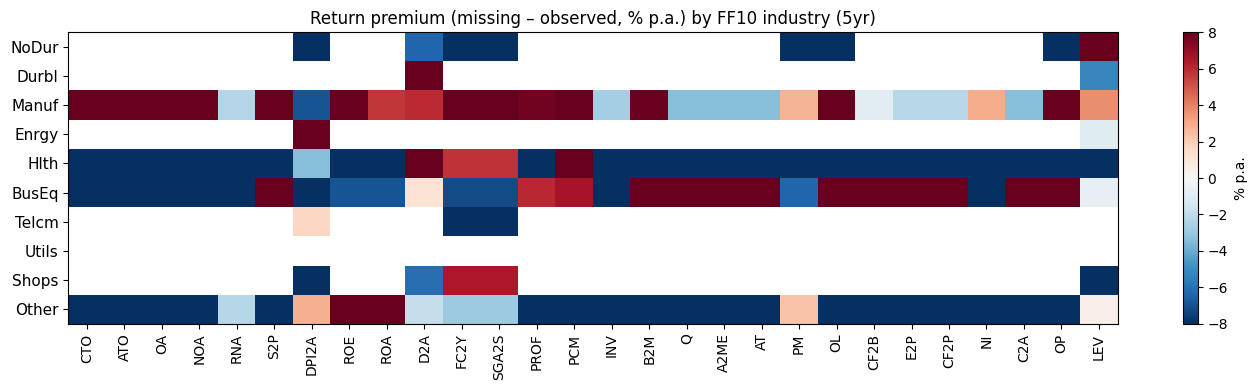

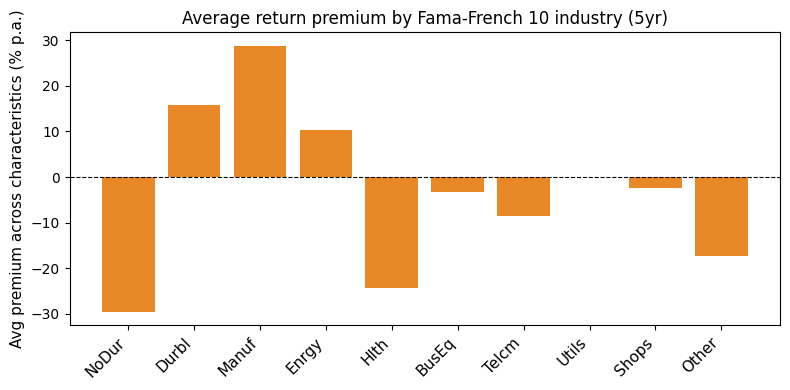

In [55]:
prem_matrix_ind = np.array([industry_results[ind]['premium'].values
                             for ind in industries_present])

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(prem_matrix_ind[:, ordered_chars_idx], aspect='auto', cmap='RdBu_r',
               vmin=-8, vmax=8)
ax.set_yticks(range(len(industries_present)))
ax.set_yticklabels(industries_present, fontsize=11)
ax.set_xticks(range(len(PORT_TGT_CHARS)))
ax.set_xticklabels(ordered_chars_names, rotation=90, fontsize=10)
ax.set_title('Return premium (missing – observed, % p.a.) by FF10 industry (5yr)', fontsize=12)
plt.colorbar(im, ax=ax, label='% p.a.')
plt.savefig('../images-pdfs/ablation_industry_heatmap_5yr.pdf', bbox_inches='tight')
plt.show()

avg_prems_ind = [industry_results[ind]['premium'].mean() for ind in industries_present]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(industries_present)), avg_prems_ind, color='#e67300', alpha=0.85)
ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
ax.set_xticks(range(len(industries_present)))
ax.set_xticklabels(industries_present, rotation=45, ha='right', fontsize=11)
ax.set_ylabel('Avg premium across characteristics (% p.a.)', fontsize=11)
ax.set_title('Average return premium by Fama-French 10 industry (5yr)', fontsize=12)
plt.savefig('../images-pdfs/ablation_industry_avg_premium_5yr.pdf', bbox_inches='tight')
plt.show()

## Segmentation 3: Operating Profitability Quintiles

In [56]:
%%time

op_ind = np.argwhere(chars == 'OP')[0][0]
op_masks = build_quintile_masks(percentile_rank_chars, op_ind)

op_results = []
for q, mask in enumerate(op_masks):
    print(f'  Computing OP quintile {q+1}/5 ...')
    res = compute_return_premium(percentile_rank_chars, regular_chars, return_panel,
                                  chars, mask)
    res['quintile'] = q + 1
    op_results.append(res)

print('Done.')

  Computing OP quintile 1/5 ...
  Computing OP quintile 2/5 ...
  Computing OP quintile 3/5 ...
  Computing OP quintile 4/5 ...
  Computing OP quintile 5/5 ...
Done.
CPU times: user 2.92 s, sys: 241 ms, total: 3.16 s
Wall time: 3.32 s


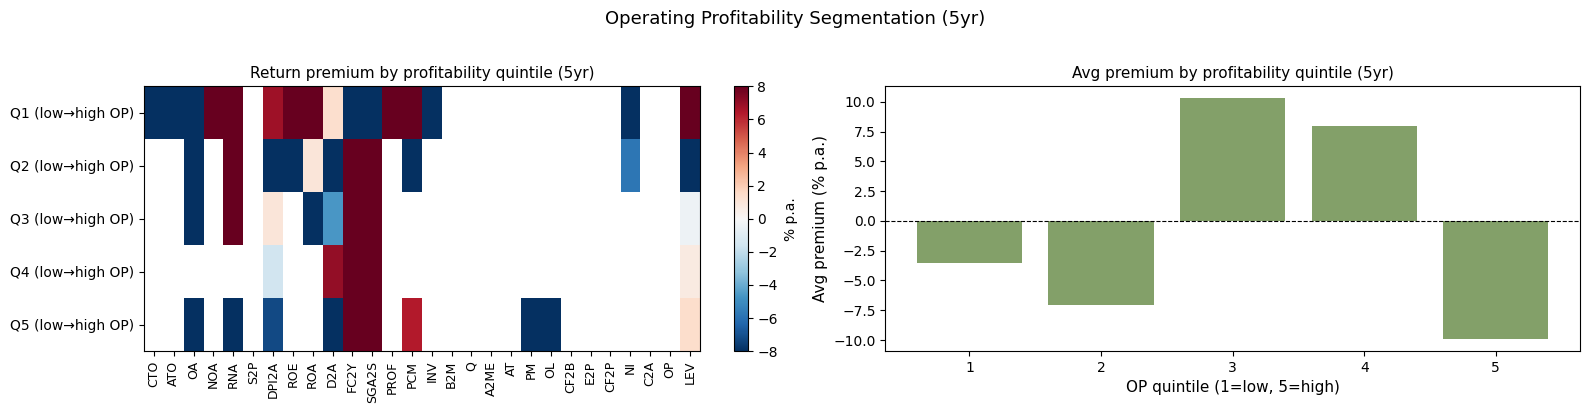

In [57]:
prem_matrix_op = np.array([r['premium'].values for r in op_results])

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

im = axes[0].imshow(prem_matrix_op[:, ordered_chars_idx], aspect='auto', cmap='RdBu_r',
                    vmin=-8, vmax=8)
axes[0].set_yticks(range(5))
axes[0].set_yticklabels([f'Q{i+1} (low→high OP)' for i in range(5)], fontsize=10)
axes[0].set_xticks(range(len(PORT_TGT_CHARS)))
axes[0].set_xticklabels(ordered_chars_names, rotation=90, fontsize=9)
axes[0].set_title('Return premium by profitability quintile (5yr)', fontsize=11)
plt.colorbar(im, ax=axes[0], label='% p.a.')

avg_prems_op = [r['premium'].mean() for r in op_results]
axes[1].bar(range(1, 6), avg_prems_op, color='#6d904f', alpha=0.85)
axes[1].axhline(0, color='k', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('OP quintile (1=low, 5=high)', fontsize=11)
axes[1].set_ylabel('Avg premium (% p.a.)', fontsize=11)
axes[1].set_title('Avg premium by profitability quintile (5yr)', fontsize=11)

plt.suptitle('Operating Profitability Segmentation (5yr)', fontsize=13, y=1.02)
plt.savefig('../images-pdfs/ablation_op_quintiles_5yr.pdf', bbox_inches='tight')
plt.show()

## Segmentation 4: Leverage Quintiles

In [58]:
%%time

lev_ind = np.argwhere(chars == 'LEV')[0][0]
lev_masks = build_quintile_masks(percentile_rank_chars, lev_ind)

lev_results = []
for q, mask in enumerate(lev_masks):
    print(f'  Computing LEV quintile {q+1}/5 ...')
    res = compute_return_premium(percentile_rank_chars, regular_chars, return_panel,
                                  chars, mask)
    res['quintile'] = q + 1
    lev_results.append(res)

print('Done.')

  Computing LEV quintile 1/5 ...
  Computing LEV quintile 2/5 ...
  Computing LEV quintile 3/5 ...
  Computing LEV quintile 4/5 ...
  Computing LEV quintile 5/5 ...
Done.
CPU times: user 3.59 s, sys: 58 ms, total: 3.65 s
Wall time: 3.69 s


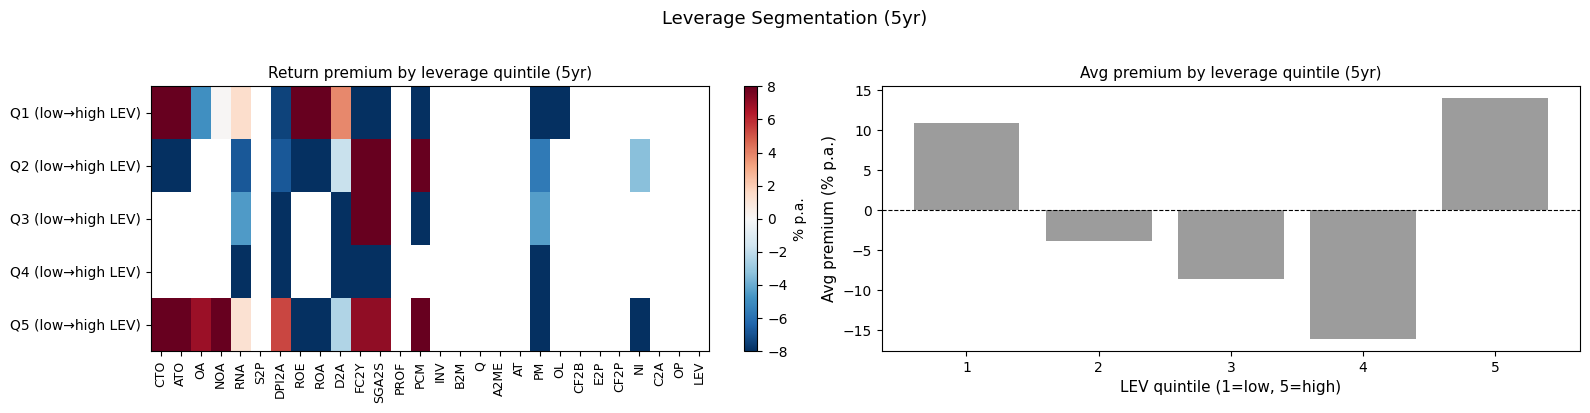

In [59]:
prem_matrix_lev = np.array([r['premium'].values for r in lev_results])

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

im = axes[0].imshow(prem_matrix_lev[:, ordered_chars_idx], aspect='auto', cmap='RdBu_r',
                    vmin=-8, vmax=8)
axes[0].set_yticks(range(5))
axes[0].set_yticklabels([f'Q{i+1} (low→high LEV)' for i in range(5)], fontsize=10)
axes[0].set_xticks(range(len(PORT_TGT_CHARS)))
axes[0].set_xticklabels(ordered_chars_names, rotation=90, fontsize=9)
axes[0].set_title('Return premium by leverage quintile (5yr)', fontsize=11)
plt.colorbar(im, ax=axes[0], label='% p.a.')

avg_prems_lev = [r['premium'].mean() for r in lev_results]
axes[1].bar(range(1, 6), avg_prems_lev, color='#8b8b8b', alpha=0.85)
axes[1].axhline(0, color='k', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('LEV quintile (1=low, 5=high)', fontsize=11)
axes[1].set_ylabel('Avg premium (% p.a.)', fontsize=11)
axes[1].set_title('Avg premium by leverage quintile (5yr)', fontsize=11)

plt.suptitle('Leverage Segmentation (5yr)', fontsize=13, y=1.02)
plt.savefig('../images-pdfs/ablation_lev_quintiles_5yr.pdf', bbox_inches='tight')
plt.show()

## Segmentation 5: Book-to-Market Quintiles (Value vs. Growth)

In [60]:
%%time

b2m_ind = np.argwhere(chars == 'B2M')[0][0]
b2m_masks = build_quintile_masks(percentile_rank_chars, b2m_ind)

b2m_results = []
for q, mask in enumerate(b2m_masks):
    print(f'  Computing B2M quintile {q+1}/5 ...')
    res = compute_return_premium(percentile_rank_chars, regular_chars, return_panel,
                                  chars, mask)
    res['quintile'] = q + 1
    b2m_results.append(res)

print('Done.')

  Computing B2M quintile 1/5 ...
  Computing B2M quintile 2/5 ...
  Computing B2M quintile 3/5 ...
  Computing B2M quintile 4/5 ...
  Computing B2M quintile 5/5 ...
Done.
CPU times: user 3.36 s, sys: 16.2 ms, total: 3.38 s
Wall time: 3.41 s


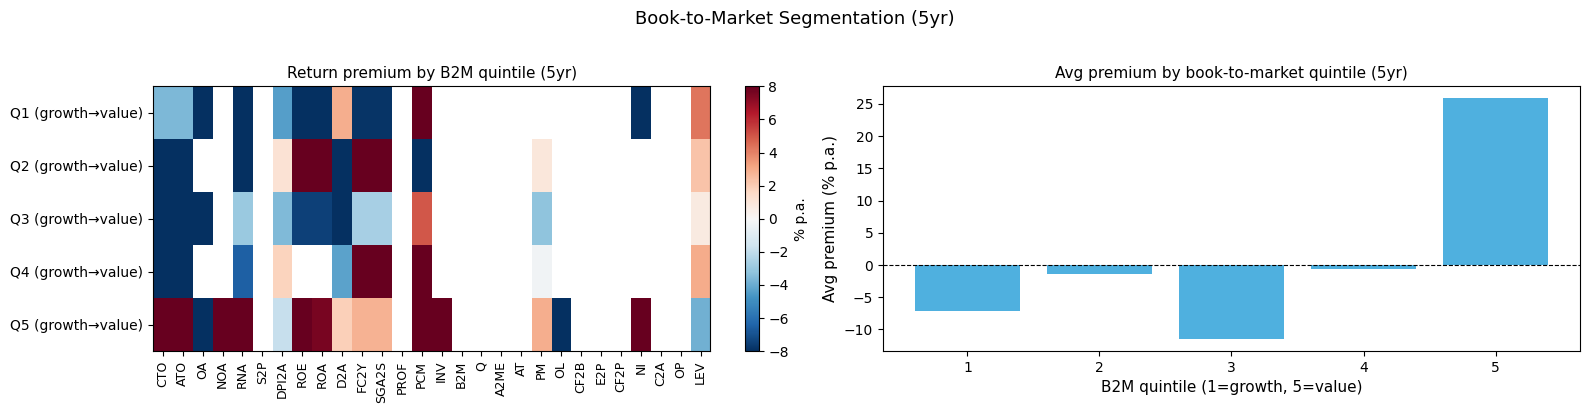

In [61]:
prem_matrix_b2m = np.array([r['premium'].values for r in b2m_results])

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

im = axes[0].imshow(prem_matrix_b2m[:, ordered_chars_idx], aspect='auto', cmap='RdBu_r',
                    vmin=-8, vmax=8)
axes[0].set_yticks(range(5))
axes[0].set_yticklabels([f'Q{i+1} (growth→value)' for i in range(5)], fontsize=10)
axes[0].set_xticks(range(len(PORT_TGT_CHARS)))
axes[0].set_xticklabels(ordered_chars_names, rotation=90, fontsize=9)
axes[0].set_title('Return premium by B2M quintile (5yr)', fontsize=11)
plt.colorbar(im, ax=axes[0], label='% p.a.')

avg_prems_b2m = [r['premium'].mean() for r in b2m_results]
axes[1].bar(range(1, 6), avg_prems_b2m, color='#30a2da', alpha=0.85)
axes[1].axhline(0, color='k', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('B2M quintile (1=growth, 5=value)', fontsize=11)
axes[1].set_ylabel('Avg premium (% p.a.)', fontsize=11)
axes[1].set_title('Avg premium by book-to-market quintile (5yr)', fontsize=11)

plt.suptitle('Book-to-Market Segmentation (5yr)', fontsize=13, y=1.02)
plt.savefig('../images-pdfs/ablation_b2m_quintiles_5yr.pdf', bbox_inches='tight')
plt.show()

## Segmentation 6: Time Sub-periods

We split the 5-year sample at January 2018 (mid-point) to compare 2016–2017 vs. 2018–2020.

In [62]:
%%time

split_date = 20180101
post_mask = np.zeros((T, N), dtype=bool)
pre_mask  = np.zeros((T, N), dtype=bool)

for t, d in enumerate(dates):
    if d >= split_date:
        post_mask[t, :] = True
    else:
        pre_mask[t, :] = True

n_pre  = int(np.sum(dates < split_date))
n_post = int(np.sum(dates >= split_date))
print(f'Pre-2018: {n_pre} months, Post-2018: {n_post} months')

print('  Computing pre-2018 ...')
pre_result  = compute_return_premium(percentile_rank_chars, regular_chars, return_panel,
                                     chars, pre_mask)
print('  Computing post-2018 ...')
post_result = compute_return_premium(percentile_rank_chars, regular_chars, return_panel,
                                     chars, post_mask)
print('Done.')

Pre-2018: 24 months, Post-2018: 36 months
  Computing pre-2018 ...
  Computing post-2018 ...
Done.
CPU times: user 1.07 s, sys: 10.1 ms, total: 1.08 s
Wall time: 1.09 s


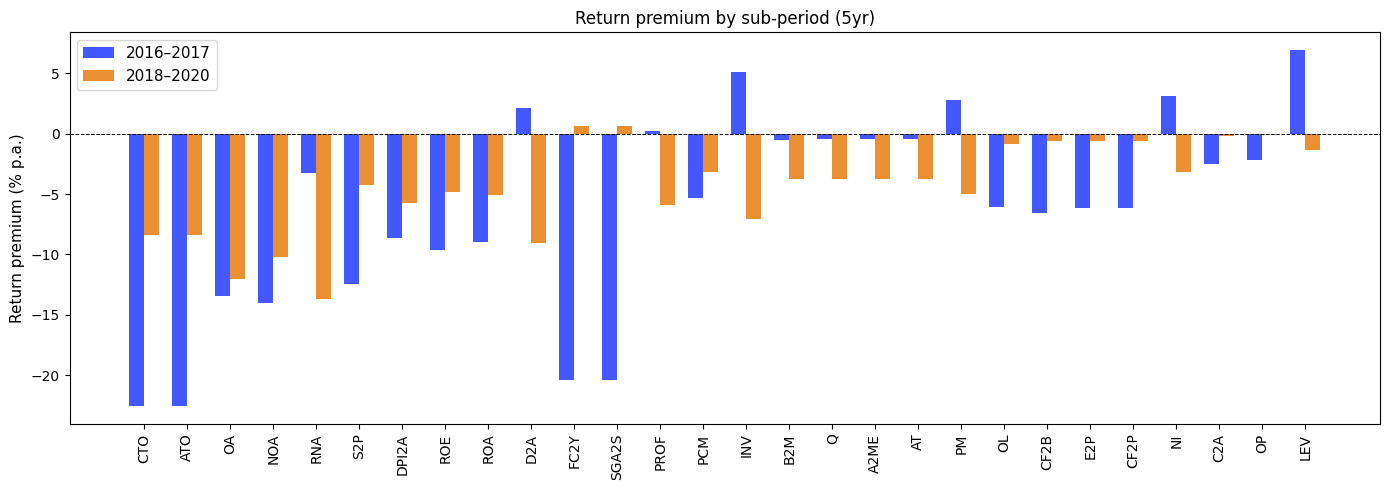

Pre-2018  avg premium: -6.17% p.a.
Post-2018 avg premium: -4.42% p.a.


In [63]:
x = np.arange(len(PORT_TGT_CHARS))
width = 0.35

pre_prems  = pre_result['premium'].values[ordered_chars_idx]
post_prems = post_result['premium'].values[ordered_chars_idx]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, pre_prems,  width, label='2016–2017', color='#152eff', alpha=0.8)
ax.bar(x + width/2, post_prems, width, label='2018–2020', color='#e67300', alpha=0.8)
ax.axhline(0, color='k', linewidth=0.7, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels(ordered_chars_names, rotation=90, fontsize=10)
ax.set_ylabel('Return premium (% p.a.)', fontsize=11)
ax.set_title('Return premium by sub-period (5yr)', fontsize=12)
ax.legend(fontsize=11)
plt.savefig('../images-pdfs/ablation_subperiod_premium_5yr.pdf', bbox_inches='tight')
plt.show()

print(f"Pre-2018  avg premium: {pre_result['premium'].mean():.2f}% p.a.")
print(f"Post-2018 avg premium: {post_result['premium'].mean():.2f}% p.a.")

## Summary: Cross-Segment Comparison

In [64]:
summary_rows = []

summary_rows.append({'Segment': 'Full sample', 'Avg premium (% p.a.)': baseline['premium'].mean(),
                     'Avg |t-stat|': baseline['t_stat'].abs().mean()})

for q in range(5):
    summary_rows.append({'Segment': f'Size Q{q+1}',
                         'Avg premium (% p.a.)': size_results[q]['premium'].mean(),
                         'Avg |t-stat|': size_results[q]['t_stat'].abs().mean()})

for ind in industries_present:
    summary_rows.append({'Segment': f'Industry: {ind}',
                         'Avg premium (% p.a.)': industry_results[ind]['premium'].mean(),
                         'Avg |t-stat|': industry_results[ind]['t_stat'].abs().mean()})

for q in range(5):
    summary_rows.append({'Segment': f'OP Q{q+1}',
                         'Avg premium (% p.a.)': op_results[q]['premium'].mean(),
                         'Avg |t-stat|': op_results[q]['t_stat'].abs().mean()})

for q in range(5):
    summary_rows.append({'Segment': f'LEV Q{q+1}',
                         'Avg premium (% p.a.)': lev_results[q]['premium'].mean(),
                         'Avg |t-stat|': lev_results[q]['t_stat'].abs().mean()})

for q in range(5):
    summary_rows.append({'Segment': f'B2M Q{q+1}',
                         'Avg premium (% p.a.)': b2m_results[q]['premium'].mean(),
                         'Avg |t-stat|': b2m_results[q]['t_stat'].abs().mean()})

summary_rows.append({'Segment': 'Pre-2018',
                     'Avg premium (% p.a.)': pre_result['premium'].mean(),
                     'Avg |t-stat|': pre_result['t_stat'].abs().mean()})
summary_rows.append({'Segment': 'Post-2018',
                     'Avg premium (% p.a.)': post_result['premium'].mean(),
                     'Avg |t-stat|': post_result['t_stat'].abs().mean()})

summary_df = pd.DataFrame(summary_rows).set_index('Segment').round(2)
summary_df

,Avg premium (% p.a.),Avg |t-stat|
Segment,,
Full sample,-4.92,0.61
Size Q1,-11.84,0.95
Size Q2,-5.88,0.52
Size Q3,-11.55,0.85
Size Q4,0.90,1.38
Size Q5,-21.81,2.31
Industry: NoDur,-29.62,1.74
Industry: Durbl,15.76,0.27
Industry: Manuf,28.82,0.56


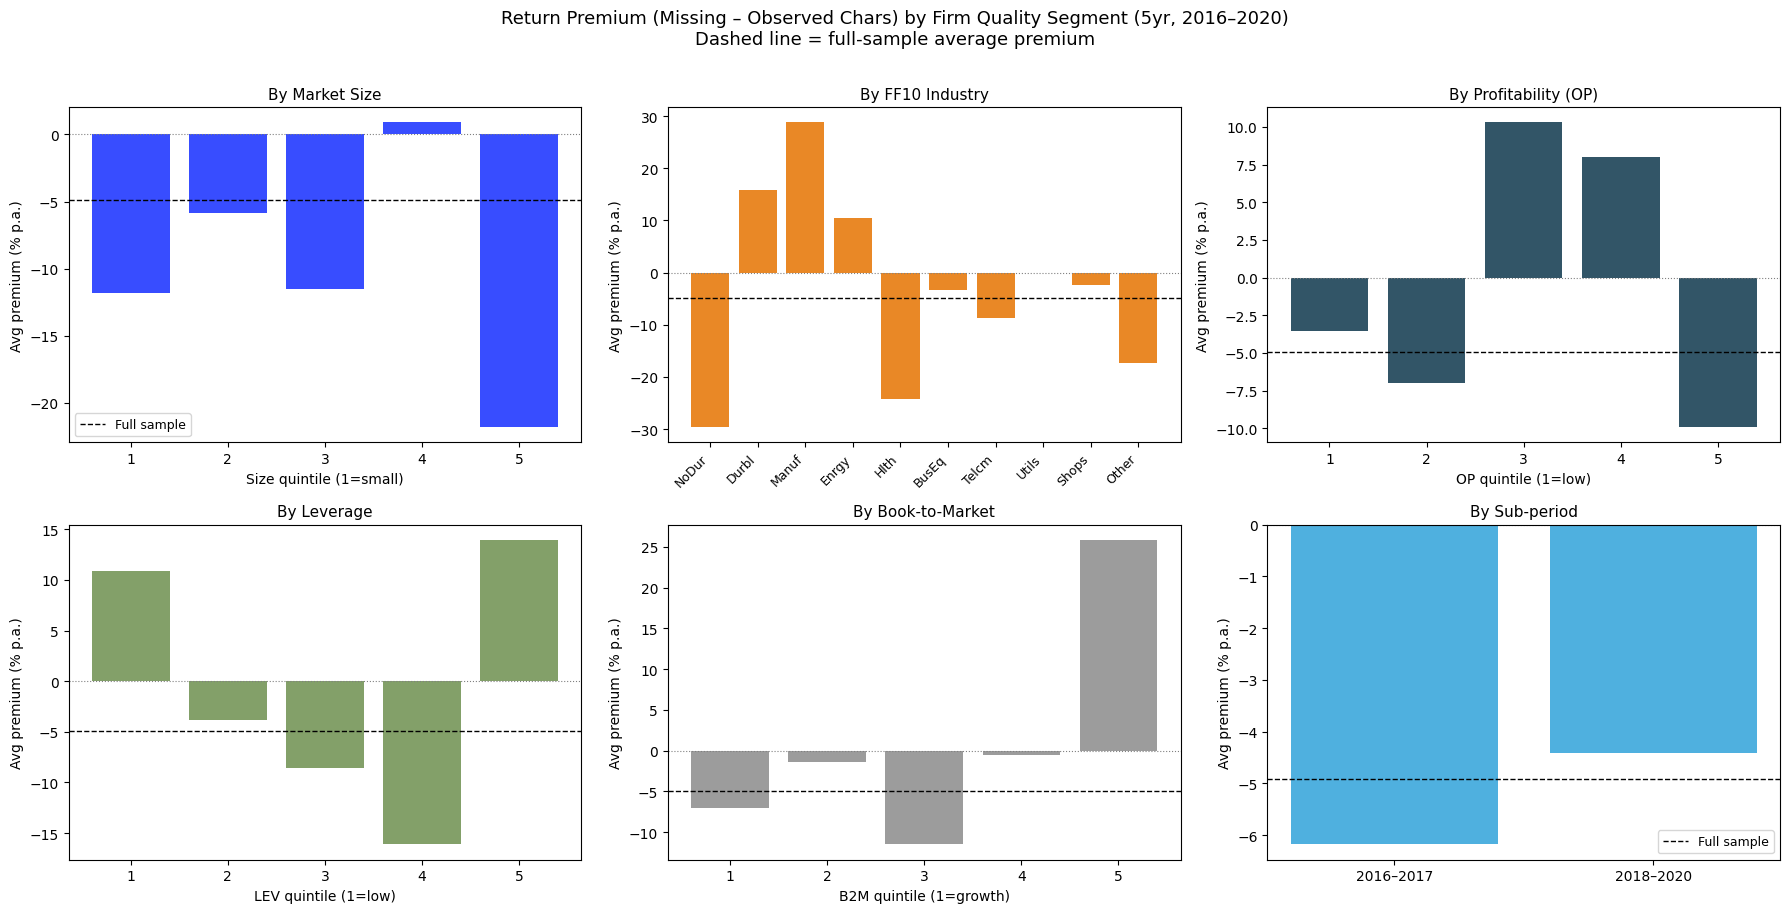

In [65]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

mycolors = ['#152eff', '#e67300', '#0e374c', '#6d904f', '#8b8b8b', '#30a2da']

axes[0, 0].bar(range(1, 6), [r['premium'].mean() for r in size_results],
               color=mycolors[0], alpha=0.85)
axes[0, 0].axhline(baseline['premium'].mean(), color='k', linestyle='--', linewidth=1,
                   label='Full sample')
axes[0, 0].axhline(0, color='gray', linestyle=':', linewidth=0.8)
axes[0, 0].set_xlabel('Size quintile (1=small)', fontsize=10)
axes[0, 0].set_ylabel('Avg premium (% p.a.)', fontsize=10)
axes[0, 0].set_title('By Market Size', fontsize=11)
axes[0, 0].legend(fontsize=9)

axes[0, 1].bar(range(len(industries_present)),
               [industry_results[ind]['premium'].mean() for ind in industries_present],
               color=mycolors[1], alpha=0.85)
axes[0, 1].axhline(baseline['premium'].mean(), color='k', linestyle='--', linewidth=1)
axes[0, 1].axhline(0, color='gray', linestyle=':', linewidth=0.8)
axes[0, 1].set_xticks(range(len(industries_present)))
axes[0, 1].set_xticklabels(industries_present, rotation=45, ha='right', fontsize=9)
axes[0, 1].set_ylabel('Avg premium (% p.a.)', fontsize=10)
axes[0, 1].set_title('By FF10 Industry', fontsize=11)

axes[0, 2].bar(range(1, 6), [r['premium'].mean() for r in op_results],
               color=mycolors[2], alpha=0.85)
axes[0, 2].axhline(baseline['premium'].mean(), color='k', linestyle='--', linewidth=1)
axes[0, 2].axhline(0, color='gray', linestyle=':', linewidth=0.8)
axes[0, 2].set_xlabel('OP quintile (1=low)', fontsize=10)
axes[0, 2].set_ylabel('Avg premium (% p.a.)', fontsize=10)
axes[0, 2].set_title('By Profitability (OP)', fontsize=11)

axes[1, 0].bar(range(1, 6), [r['premium'].mean() for r in lev_results],
               color=mycolors[3], alpha=0.85)
axes[1, 0].axhline(baseline['premium'].mean(), color='k', linestyle='--', linewidth=1)
axes[1, 0].axhline(0, color='gray', linestyle=':', linewidth=0.8)
axes[1, 0].set_xlabel('LEV quintile (1=low)', fontsize=10)
axes[1, 0].set_ylabel('Avg premium (% p.a.)', fontsize=10)
axes[1, 0].set_title('By Leverage', fontsize=11)

axes[1, 1].bar(range(1, 6), [r['premium'].mean() for r in b2m_results],
               color=mycolors[4], alpha=0.85)
axes[1, 1].axhline(baseline['premium'].mean(), color='k', linestyle='--', linewidth=1)
axes[1, 1].axhline(0, color='gray', linestyle=':', linewidth=0.8)
axes[1, 1].set_xlabel('B2M quintile (1=growth)', fontsize=10)
axes[1, 1].set_ylabel('Avg premium (% p.a.)', fontsize=10)
axes[1, 1].set_title('By Book-to-Market', fontsize=11)

axes[1, 2].bar([0, 1],
               [pre_result['premium'].mean(), post_result['premium'].mean()],
               color=mycolors[5], alpha=0.85)
axes[1, 2].axhline(baseline['premium'].mean(), color='k', linestyle='--', linewidth=1,
                   label='Full sample')
axes[1, 2].axhline(0, color='gray', linestyle=':', linewidth=0.8)
axes[1, 2].set_xticks([0, 1])
axes[1, 2].set_xticklabels(['2016–2017', '2018–2020'], fontsize=10)
axes[1, 2].set_ylabel('Avg premium (% p.a.)', fontsize=10)
axes[1, 2].set_title('By Sub-period', fontsize=11)
axes[1, 2].legend(fontsize=9)

plt.suptitle(
    'Return Premium (Missing – Observed Chars) by Firm Quality Segment (5yr, 2016–2020)\n'
    'Dashed line = full-sample average premium',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig('../images-pdfs/ablation_summary_6panel_5yr.pdf', bbox_inches='tight')
plt.show()

## Characteristic-Level Premium: per-segment scatter

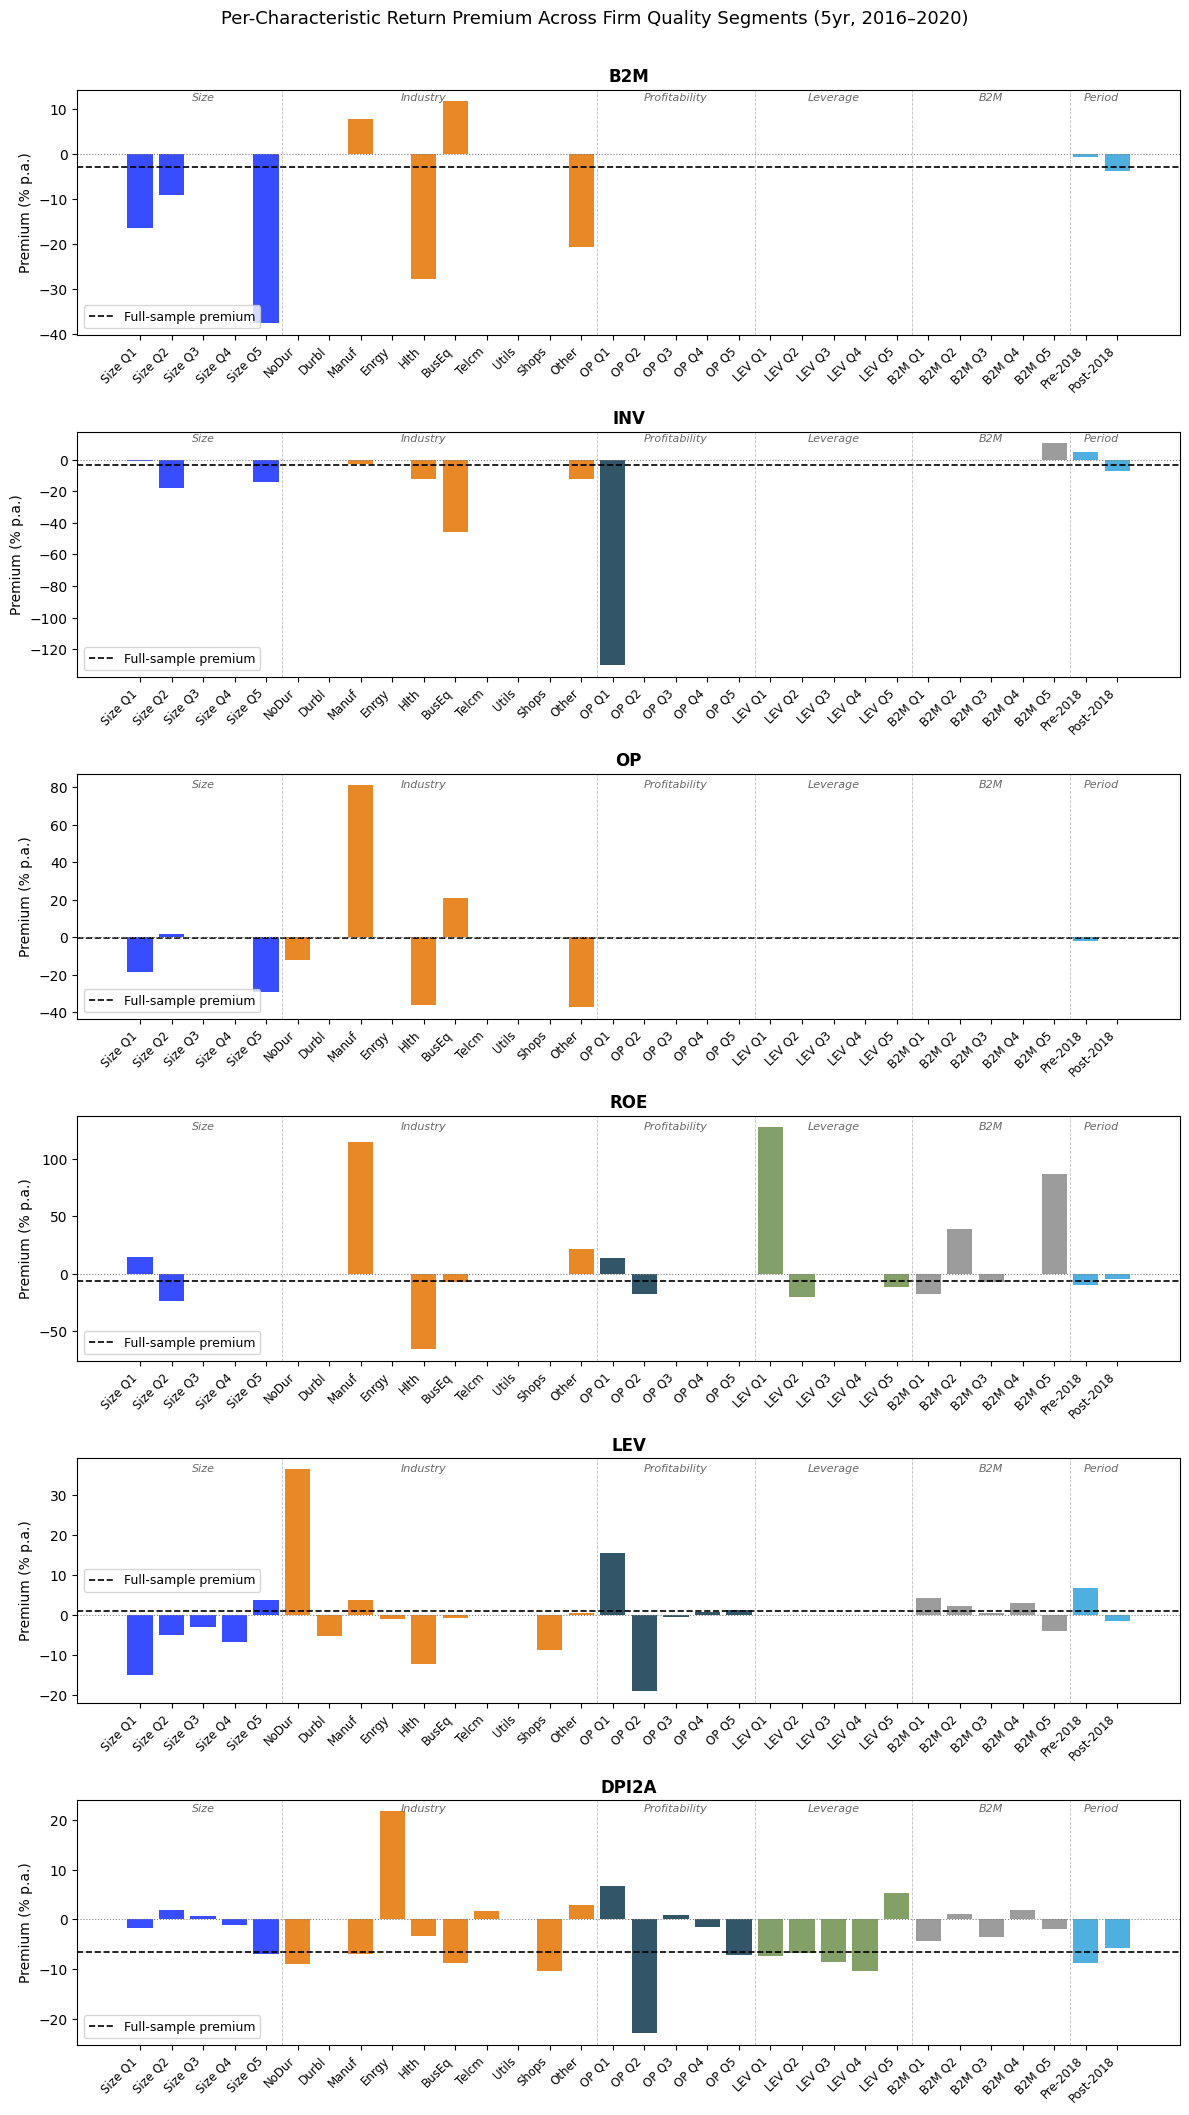

In [66]:
HIGHLIGHT_CHARS = ['B2M', 'INV', 'OP', 'ROE', 'LEV', 'DPI2A']

fig, axes = plt.subplots(len(HIGHLIGHT_CHARS), 1, figsize=(12, 3.5 * len(HIGHLIGHT_CHARS)))

x_size = [f'Size Q{q+1}' for q in range(5)]
x_ind  = [f'{ind}' for ind in industries_present]
x_op   = [f'OP Q{q+1}' for q in range(5)]
x_lev  = [f'LEV Q{q+1}' for q in range(5)]
x_b2m  = [f'B2M Q{q+1}' for q in range(5)]
x_sub  = ['Pre-2018', 'Post-2018']

all_labels = x_size + x_ind + x_op + x_lev + x_b2m + x_sub
dividers = [5, 5 + len(industries_present), 5 + len(industries_present) + 5,
            5 + len(industries_present) + 10, 5 + len(industries_present) + 15]

for ax, char_name in zip(axes, HIGHLIGHT_CHARS):
    if char_name not in PORT_TGT_CHARS:
        ax.set_visible(False)
        continue

    premiums = (
        [size_results[q].loc[char_name, 'premium'] for q in range(5)] +
        [industry_results[ind].loc[char_name, 'premium'] for ind in industries_present] +
        [op_results[q].loc[char_name, 'premium'] for q in range(5)] +
        [lev_results[q].loc[char_name, 'premium'] for q in range(5)] +
        [b2m_results[q].loc[char_name, 'premium'] for q in range(5)] +
        [pre_result.loc[char_name, 'premium'], post_result.loc[char_name, 'premium']]
    )

    colors_bar = (['#152eff'] * 5 + ['#e67300'] * len(industries_present) +
                  ['#0e374c'] * 5 + ['#6d904f'] * 5 + ['#8b8b8b'] * 5 + ['#30a2da'] * 2)

    x_pos = np.arange(len(premiums))
    ax.bar(x_pos, premiums, color=colors_bar, alpha=0.85)
    ax.axhline(baseline.loc[char_name, 'premium'], color='k', linestyle='--',
               linewidth=1.2, label='Full-sample premium')
    ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)

    for div in dividers:
        ax.axvline(div - 0.5, color='gray', linestyle='--', linewidth=0.6, alpha=0.5)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(all_labels, rotation=45, ha='right', fontsize=8.5)
    ax.set_ylabel('Premium (% p.a.)', fontsize=10)
    ax.set_title(f'{char_name}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

    group_centers = [2, 5 + len(industries_present)/2 - 1,
                     5 + len(industries_present) + 2,
                     5 + len(industries_present) + 7,
                     5 + len(industries_present) + 12,
                     5 + len(industries_present) + 15.5]
    group_labels = ['Size', 'Industry', 'Profitability', 'Leverage', 'B2M', 'Period']
    y_top = ax.get_ylim()[1]
    for gx, gl in zip(group_centers, group_labels):
        ax.text(gx, y_top * 0.97, gl, ha='center', va='top', fontsize=8,
                color='dimgray', style='italic')

plt.suptitle('Per-Characteristic Return Premium Across Firm Quality Segments (5yr, 2016–2020)',
             fontsize=13, y=1.005)
plt.tight_layout()
plt.savefig('../images-pdfs/ablation_per_char_segments_5yr.pdf', bbox_inches='tight')
plt.show()